# Full-conversation intent discovery

This notebook embeds every message in each conversation, compares clustering methods, inspects central/boundary/random examples, and only then synthesizes an actionable taxonomy. The source JSONL is never overwritten; labels are written to a versioned output.

In [7]:
import asyncio
import hashlib
import json
import random
import re
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)

DATA_PATH = Path("../data/processed/conversations.jsonl")
FAISS_DIR = Path("../data/faiss_full_conversation")
META_PATH = FAISS_DIR / "metadata.json"
OUTPUT_PATH = Path("../data/processed/conversations_with_intents_full_v1.jsonl")
MODEL = "nomic-embed-text:latest"
MAX_CONCURRENCY = 4  # RTX 4050 6 GB starting point; Ollama OLLAMA_NUM_PARALLEL also matters.
RETRY_ATTEMPTS = 3
SEED = 42
PREPROCESSING_VERSION = "full_conversation_roles_mentions_urls_v2"
random.seed(SEED)
np.random.seed(SEED)


def load_jsonl(path):
    with path.open(encoding="utf-8") as file:
        return [json.loads(line) for line in file if line.strip()]


def sha256(path):
    digest = hashlib.sha256()
    with path.open("rb") as file:
        for chunk in iter(lambda: file.read(1048576), b""):
            digest.update(chunk)
    return digest.hexdigest()


def normalize_message_text(text):
    text = str(text or "")
    text = re.sub(r"https?://\S+|www\.\S+", " [URL] ", text)
    text = re.sub(r"@[A-Za-z0-9_]+", " [MENTION] ", text)
    return re.sub(r"\s+", " ", text).strip()


def prepare_conversation_for_embedding(conversation):
    lines = []
    for message in conversation.get("messages", []):
        role = str(message.get("role", "unknown")).upper()
        lines.append(f"{role}: {normalize_message_text(message.get('text', ''))}")
    return "\n".join(lines)


conversations = load_jsonl(DATA_PATH)
conversation_ids = [str(item["conversation_id"]) for item in conversations]
full_texts = [prepare_conversation_for_embedding(item) for item in conversations]
opening_texts = [
    normalize_message_text(item.get("messages", [{}])[0].get("text", ""))
    if item.get("messages") else ""
    for item in conversations
]
customer_texts = [
    " ".join(
        normalize_message_text(message.get("text", ""))
        for message in item.get("messages", [])
        if message.get("role") == "customer"
    )
    for item in conversations
]
representation_summary = pd.DataFrame({
    "representation": ["opening", "customer_only", "full_conversation"],
    "mean_chars": [np.mean([len(text) for text in opening_texts]), np.mean([len(text) for text in customer_texts]), np.mean([len(text) for text in full_texts])],
    "median_chars": [np.median([len(text) for text in opening_texts]), np.median([len(text) for text in customer_texts]), np.median([len(text) for text in full_texts])],
})
print(f"Conversations: {len(conversations):,}")
display(representation_summary)
print("Embedding unit: complete chronological conversation with CUSTOMER/AGENT markers.")
print(f"Preprocessing example: {full_texts[0][:240]}")

Conversations: 26,388


,representation,mean_chars,median_chars
0,opening,130.052941,125.0
1,customer_only,217.046991,140.0
2,full_conversation,390.127255,286.0


Embedding unit: complete chronological conversation with CUSTOMER/AGENT markers.
Preprocessing example: CUSTOMER: [MENTION] have a flight at 330pm (45mins) I’m almost to Lax. I’m legally blind and didn’t know where to let you know I need assistance. [MENTION] Could you have someone on your lax team available to guide me to my gate ASAP
AGENT:


## 1. Full-conversation representation and preprocessing

In [8]:
from langchain_community.vectorstores import FAISS
from langchain_ollama import OllamaEmbeddings


def recover_faiss(store):
    count = store.index.ntotal
    matrix = store.index.reconstruct_n(0, count).astype("float32")
    ids, texts = [], []
    for index in range(count):
        document = store.docstore.search(store.index_to_docstore_id[index])
        ids.append(str(document.metadata["conversation_id"]))
        texts.append(document.page_content)
    return matrix, ids, texts


def validate_loaded_store(store, metadata):
    matrix, ids, texts = recover_faiss(store)
    checks = {
        "model": metadata.get("model") == MODEL,
        "source_hash": metadata.get("source_hash") == sha256(DATA_PATH),
        "preprocessing_version": metadata.get("preprocessing_version") == PREPROCESSING_VERSION,
        "representation_type": metadata.get("representation_type") == "full_conversation",
        "count": len(ids) == len(conversation_ids),
        "ids": ids == conversation_ids,
        "texts": texts == full_texts,
        "unique_ids": len(ids) == len(set(ids)),
        "finite": bool(np.isfinite(matrix).all()),
        "dimension": matrix.ndim == 2 and matrix.shape[1] > 0,
    }
    return checks, matrix, ids, texts


embeddings_model = OllamaEmbeddings(model=MODEL)
if FAISS_DIR.exists() and META_PATH.exists():
    store = FAISS.load_local(
        str(FAISS_DIR),
        embeddings_model,
        allow_dangerous_deserialization=True,
    )
    metadata = json.loads(META_PATH.read_text(encoding="utf-8"))
    checks, embedding_matrix, faiss_ids, faiss_texts = validate_loaded_store(store, metadata)
    print(checks)
    assert all(checks.values()), "Existing FAISS store is stale or mismatched. Delete it before reuse."
else:
    semaphore = asyncio.Semaphore(MAX_CONCURRENCY)
    progress = {"completed": 0}
    progress_lock = asyncio.Lock()

    async def embed_one(text, total):
        for attempt in range(RETRY_ATTEMPTS):
            try:
                async with semaphore:
                    vector = await embeddings_model.aembed_query(text)
                async with progress_lock:
                    progress["completed"] += 1
                    completed = progress["completed"]
                    if completed == 1 or completed % 100 == 0 or completed == total:
                        print(f"Embedded {completed:,}/{total:,}")
                return vector
            except Exception:
                if attempt == RETRY_ATTEMPTS - 1:
                    raise
                await asyncio.sleep(0.5 * (attempt + 1))

    vectors = await asyncio.gather(*(embed_one(text, len(full_texts)) for text in full_texts))
    store = FAISS.from_embeddings(
        list(zip(full_texts, vectors)),
        embeddings_model,
        metadatas=[
            {"conversation_id": conversation_id, "representation": "full_conversation"}
            for conversation_id in conversation_ids
        ],
    )
    FAISS_DIR.mkdir(parents=True, exist_ok=True)
    store.save_local(str(FAISS_DIR))
    embedding_matrix, faiss_ids, faiss_texts = recover_faiss(store)
    metadata = {
        "model": MODEL,
        "dimension": int(embedding_matrix.shape[1]),
        "source_file": str(DATA_PATH),
        "source_hash": sha256(DATA_PATH),
        "conversation_count": len(conversations),
        "embedded_count": len(faiss_ids),
        "preprocessing_version": PREPROCESSING_VERSION,
        "representation_type": "full_conversation",
        "created_at_utc": datetime.now(timezone.utc).isoformat(),
        "vector_store_version": "full_conversation_v1",
        "conversation_ids": faiss_ids,
    }
    META_PATH.write_text(json.dumps(metadata, indent=2), encoding="utf-8")
    print(f"Saved fresh full-conversation FAISS store: {len(faiss_ids):,} vectors")

assert len(faiss_ids) == len(conversation_ids)
assert faiss_ids == conversation_ids
assert faiss_texts == full_texts
print(f"Embedding integrity passed: {len(faiss_ids):,} vectors, dimension {embedding_matrix.shape[1]}")
normalized = embedding_matrix / np.maximum(np.linalg.norm(embedding_matrix, axis=1, keepdims=True), 1e-12)

Embedded 1/26,388
Embedded 100/26,388
Embedded 200/26,388
Embedded 300/26,388
Embedded 400/26,388
Embedded 500/26,388
Embedded 600/26,388
Embedded 700/26,388
Embedded 800/26,388
Embedded 900/26,388
Embedded 1,000/26,388
Embedded 1,100/26,388
Embedded 1,200/26,388
Embedded 1,300/26,388
Embedded 1,400/26,388
Embedded 1,500/26,388
Embedded 1,600/26,388
Embedded 1,700/26,388
Embedded 1,800/26,388
Embedded 1,900/26,388
Embedded 2,000/26,388
Embedded 2,100/26,388
Embedded 2,200/26,388
Embedded 2,300/26,388
Embedded 2,400/26,388
Embedded 2,500/26,388
Embedded 2,600/26,388
Embedded 2,700/26,388
Embedded 2,800/26,388
Embedded 2,900/26,388
Embedded 3,000/26,388
Embedded 3,100/26,388
Embedded 3,200/26,388
Embedded 3,300/26,388
Embedded 3,400/26,388
Embedded 3,500/26,388
Embedded 3,600/26,388
Embedded 3,700/26,388
Embedded 3,800/26,388
Embedded 3,900/26,388
Embedded 4,000/26,388
Embedded 4,100/26,388
Embedded 4,200/26,388
Embedded 4,300/26,388
Embedded 4,400/26,388
Embedded 4,500/26,388
Embedded 4

## Model comparison: normalized KMeans and HDBSCAN

e:\01_Projects\02_Main\Hiver_2\customer_support_agent\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
e:\01_Projects\02_Main\Hiver_2\customer_support_agent\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,model,parameters,cluster_count,noise_percent,largest_cluster_percent,smallest_cluster_percent,silhouette,davies_bouldin,calinski_harabasz,stability
18,umap_hdbscan,"n_components=15, min_cluster_size=100, min_sam...",34,50.738972,5.343338,0.382750,0.700172,0.642758,11251.273501,NaN
19,umap_hdbscan,"n_components=15, min_cluster_size=250, min_sam...",2,1.205093,97.820979,0.973928,0.418842,0.559181,930.380185,NaN
22,agglomerative,"k=10, average cosine",10,0.000000,99.935577,0.003790,0.125849,1.322614,2.222122,NaN
0,normalized_kmeans,"k=6, n_init=20",6,0.000000,25.159163,8.473549,0.070363,3.997545,832.061183,0.998396
2,normalized_kmeans,"k=8, n_init=20",8,0.000000,17.651963,7.529938,0.058851,4.279007,681.403984,0.998121
1,normalized_kmeans,"k=7, n_init=20",7,0.000000,19.785509,8.397757,0.057576,4.291040,748.342873,0.997250
3,normalized_kmeans,"k=9, n_init=20",9,0.000000,17.610277,6.779597,0.051862,4.212254,623.515450,0.977387
5,normalized_kmeans,"k=11, n_init=20",11,0.000000,16.515083,4.911323,0.049584,4.154499,538.367521,0.933124
4,normalized_kmeans,"k=10, n_init=20",10,0.000000,16.628771,6.548431,0.046262,4.252387,576.367454,0.975579
6,normalized_kmeans,"k=12, n_init=20",12,0.000000,15.935274,4.596786,0.045125,4.165115,505.444029,0.766356


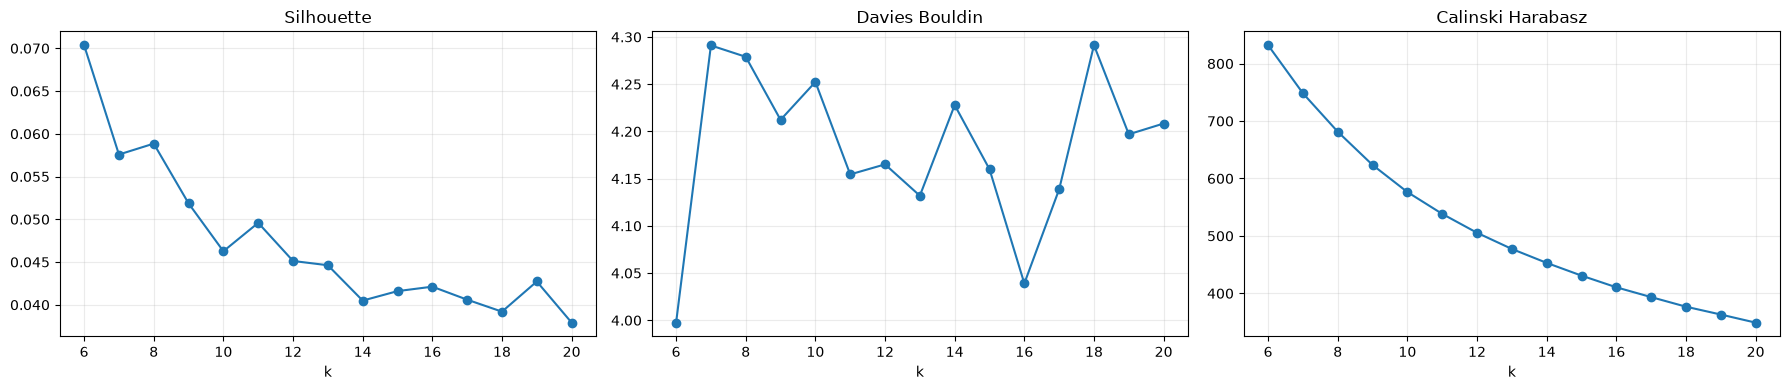

Metrics are diagnostic; semantic coherence, actionable boundaries, stability, and noise are also required.


In [9]:
import hdbscan
import umap


def evaluate_model(name, labels, data, parameters, stability_value=np.nan):
    labels = np.asarray(labels)
    mask = labels != -1
    values, counts = np.unique(labels[mask], return_counts=True)
    row = {
        "model": name,
        "parameters": parameters,
        "cluster_count": len(values),
        "noise_percent": (1 - mask.mean()) * 100,
        "largest_cluster_percent": (counts.max() / len(labels) * 100) if len(counts) else 0,
        "smallest_cluster_percent": (counts.min() / len(labels) * 100) if len(counts) else 0,
        "silhouette": np.nan,
        "davies_bouldin": np.nan,
        "calinski_harabasz": np.nan,
        "stability": stability_value,
    }
    if len(values) > 1 and mask.sum() > 2:
        row.update(
            silhouette=silhouette_score(data[mask], labels[mask], metric="cosine"),
            davies_bouldin=davies_bouldin_score(data[mask], labels[mask]),
            calinski_harabasz=calinski_harabasz_score(data[mask], labels[mask]),
        )
    return row


model_rows = []
kmeans_labels = {}
for k in range(6, 21):
    runs = [
        KMeans(n_clusters=k, n_init=20, random_state=seed).fit_predict(normalized)
        for seed in [SEED, SEED + 1, SEED + 2]
    ]
    labels = runs[0]
    ari = np.mean([adjusted_rand_score(labels, other) for other in runs[1:]])
    model_rows.append(evaluate_model("normalized_kmeans", labels, normalized, f"k={k}, n_init=20", ari))
    kmeans_labels[k] = labels

for min_size, min_samples in [(100, 10), (250, 25), (500, 50)]:
    labels = hdbscan.HDBSCAN(min_cluster_size=min_size, min_samples=min_samples, metric="euclidean").fit_predict(normalized)
    model_rows.append(evaluate_model("hdbscan", labels, normalized, f"min_cluster_size={min_size}, min_samples={min_samples}"))

umap15 = umap.UMAP(n_neighbors=30, n_components=15, metric="cosine", random_state=SEED).fit_transform(normalized)
umap2 = umap.UMAP(n_neighbors=30, n_components=2, metric="cosine", random_state=SEED).fit_transform(normalized)
for min_size, min_samples in [(100, 10), (250, 25), (500, 50)]:
    labels = hdbscan.HDBSCAN(min_cluster_size=min_size, min_samples=min_samples).fit_predict(umap15)
    model_rows.append(evaluate_model("umap_hdbscan", labels, umap15, f"n_components=15, min_cluster_size={min_size}, min_samples={min_samples}"))

full_tfidf = TfidfVectorizer(stop_words="english", min_df=5, max_features=20000, ngram_range=(1, 2))
full_tfidf_matrix = full_tfidf.fit_transform(full_texts)
full_tfidf_labels = KMeans(n_clusters=10, n_init=20, random_state=SEED).fit_predict(full_tfidf_matrix)
model_rows.append(evaluate_model("tfidf_kmeans", full_tfidf_labels, full_tfidf_matrix.toarray(), "full conversation, k=10, n_init=20"))

agglo = AgglomerativeClustering(n_clusters=10, metric="cosine", linkage="average")
agglo_labels = agglo.fit_predict(normalized)
model_rows.append(evaluate_model("agglomerative", agglo_labels, normalized, "k=10, average cosine"))

model_results = pd.DataFrame(model_rows)
display(model_results.sort_values("silhouette", ascending=False))
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
kmeans_results = model_results[model_results["model"] == "normalized_kmeans"].copy()
kmeans_results["k"] = kmeans_results["parameters"].str.extract(r"k=(\d+)")[0].astype(int)
for metric, axis in zip(["silhouette", "davies_bouldin", "calinski_harabasz"], axes):
    kmeans_results.plot(x="k", y=metric, marker="o", ax=axis, legend=False)
    axis.set_title(metric.replace("_", " ").title())
    axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()
print("Metrics are diagnostic; semantic coherence, actionable boundaries, stability, and noise are also required.")

## Central, boundary, and random examples

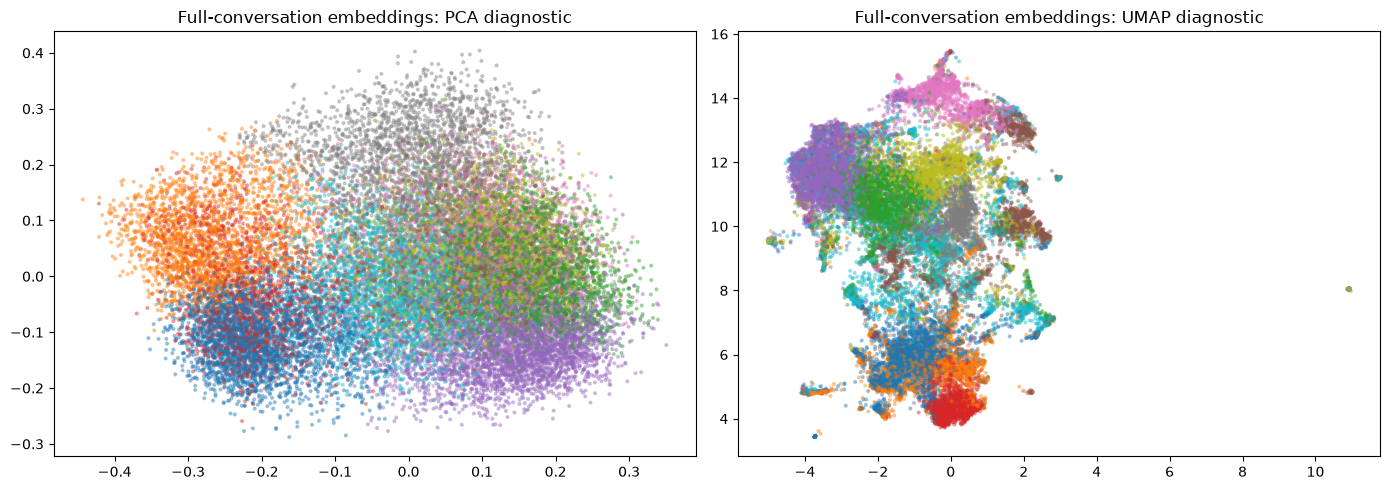


CLUSTER 0 | size=3,233
-- CENTRAL --
[1776092] CUSTOMER: i had a nice flight on [MENTION]
AGENT: [MENTION] We're glad to hear it! We hope to see you back on board for many great #AAdventures.
[332557] CUSTOMER: I am flying [MENTION] Thanks to [MENTION] [MENTION] So happy!
AGENT: [MENTION] We're so excited to welcome you on board, Eric! We'll take great care of you.
CUSTOMER: [MENTION] [MENTION] Thanks for taking care of my people [MENTION]
[1621677] CUSTOMER: Thank you, [MENTION] for an amazing flight! [URL]
AGENT: [MENTION] We loved seeing you up front and hope that you get some much needed rest! We can't wait to fly with you again soon, Kristen.
[1092731] CUSTOMER: ✈️✈️✈️ [MENTION] [URL]
AGENT: [MENTION] Nice! Everything looks best a 30,000 feet and we're happy to see you again today.
CUSTOMER: [MENTION] Always a pleasure flying with American 🙌
AGENT: [MENTION] It's always a pleasure to see you on board!
[1237237] CUSTOMER: Thanks [MENTION] for doing so much to make our families fli

In [10]:
SELECTED_K = 10
labels = kmeans_labels[SELECTED_K]
pca_2d = PCA(2, random_state=SEED).fit_transform(normalized)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(pca_2d[:, 0], pca_2d[:, 1], c=labels, s=4, alpha=0.35, cmap="tab10")
axes[0].set_title("Full-conversation embeddings: PCA diagnostic")
axes[1].scatter(umap2[:, 0], umap2[:, 1], c=labels, s=4, alpha=0.35, cmap="tab10")
axes[1].set_title("Full-conversation embeddings: UMAP diagnostic")
plt.tight_layout()
plt.show()


def inspect_cluster(cluster_id, limit=10):
    indices = np.where(labels == cluster_id)[0]
    center = normalized[indices].mean(0)
    center /= max(np.linalg.norm(center), 1e-12)
    distances = 1 - normalized[indices] @ center
    order = np.argsort(distances)
    print(f"\nCLUSTER {cluster_id} | size={len(indices):,}")
    choices = [
        ("CENTRAL", order[:limit]),
        ("BOUNDARY", order[-limit:]),
        ("RANDOM", np.random.default_rng(SEED).choice(len(indices), min(limit, len(indices)), replace=False)),
    ]
    for title, chosen in choices:
        print(f"-- {title} --")
        for position in chosen:
            index = indices[position]
            print(f"[{conversation_ids[index]}] {full_texts[index]}")


for cluster_id in range(SELECTED_K):
    inspect_cluster(cluster_id)

## Evidence summary before taxonomy

No intent labels are assigned in this stage. Review model metrics, representation coverage, distinctive terms, and central/boundary/random examples before defining the taxonomy.

In [11]:
cluster_sizes = pd.Series(labels).value_counts().sort_index()
cluster_summary = pd.DataFrame({
    "cluster": cluster_sizes.index,
    "count": cluster_sizes.values,
    "percent": (cluster_sizes.values / len(labels) * 100).round(2),
})

term_summary = {}
for cluster_id in range(SELECTED_K):
    indices = np.where(labels == cluster_id)[0]
    vectorizer = TfidfVectorizer(stop_words="english", max_features=12, ngram_range=(1, 2))
    cluster_matrix = vectorizer.fit_transform([full_texts[index] for index in indices])
    scores = np.asarray(cluster_matrix.mean(axis=0)).ravel()
    term_summary[cluster_id] = [
        vectorizer.get_feature_names_out()[index]
        for index in np.argsort(scores)[-10:][::-1]
    ]

print("Cluster sizes:")
display(cluster_summary)
print("Distinctive full-conversation TF-IDF terms by cluster:")
for cluster_id, terms in term_summary.items():
    print(f"{cluster_id}: {', '.join(terms)}")

print("No labels are assigned until this evidence has been reviewed.")

Cluster sizes:


,cluster,count,percent
0,0,3233,12.25
1,1,2224,8.43
2,2,2907,11.02
3,3,1728,6.55
4,4,4388,16.63
5,5,2039,7.73
6,6,1958,7.42
7,7,2453,9.30
8,8,2553,9.67
9,9,2905,11.01


Distinctive full-conversation TF-IDF terms by cluster:
0: mention, customer, agent, agent mention, flight, url, customer mention, url agent, thanks, great
1: mention, customer, agent, agent mention, url, customer mention, url agent, thanks, great, mention mention
2: mention, customer, customer mention, agent, flight, agent mention, dm, sorry, help, record
3: mention, customer, agent, agent mention, flight, customer mention, aateam, thanks, ll, great
4: mention, customer, agent, customer mention, agent mention, flight, time, sorry, delay, ll
5: mention, customer, customer mention, agent, agent mention, seat, flight, seats, url, ticket
6: mention, customer, agent, customer mention, agent mention, bag, baggage, bags, team, check
7: mention, customer, agent, agent mention, customer mention, dm, help, ll, service, locator
8: mention, customer, agent, customer mention, agent mention, flight, sorry, want, dm, team
9: mention, customer, agent, customer mention, agent mention, flight, url, dm, 

## Final taxonomy and safe versioned output

This is intentionally after all model comparisons and semantic inspection. Define labels from the evidence above, document boundaries, then write a new versioned file without modifying the source.

In [12]:
# Taxonomy synthesis follows the full-conversation model comparison and example audit.
# Clusters 0 and 3 both contain praise/kudos for flights and crews, so they merge.
cluster_to_taxonomy = {
    0: {"domain": "Experience", "intent": "Positive experience", "sub_intent": "Flight or crew praise", "interaction_type": "positive"},
    1: {"domain": "Social", "intent": "Social acknowledgement", "sub_intent": "Thanks or casual mention", "interaction_type": "social"},
    2: {"domain": "Flight", "intent": "Disruption recovery", "sub_intent": "Cancellation, rebooking, missed connection, or compensation", "interaction_type": "support"},
    3: {"domain": "Experience", "intent": "Positive experience", "sub_intent": "Flight or crew praise", "interaction_type": "positive"},
    4: {"domain": "Flight", "intent": "Flight delay", "sub_intent": "Late departure, arrival, gate, or tarmac wait", "interaction_type": "support"},
    5: {"domain": "Seating and fares", "intent": "Seats and fares", "sub_intent": "Seat assignment, upgrade, basic fare, or paid seating", "interaction_type": "support"},
    6: {"domain": "Baggage", "intent": "Baggage issues", "sub_intent": "Lost, delayed, damaged, checked, or carry-on baggage", "interaction_type": "support"},
    7: {"domain": "Customer service", "intent": "Service complaint", "sub_intent": "Agent, staff, responsiveness, or support quality", "interaction_type": "support"},
    8: {"domain": "Customer service", "intent": "General dissatisfaction", "sub_intent": "Broad negative experience without one dominant issue", "interaction_type": "sentiment"},
    9: {"domain": "Travel information", "intent": "Flight information", "sub_intent": "Flight status, policy, route, schedule, or general question", "interaction_type": "support"},
}
intent_definitions = {
    "Positive experience": "Praise or thanks for a completed flight, crew, or staff experience.",
    "Social acknowledgement": "Short social contact, thanks, casual mention, or low-context exchange without a support problem.",
    "Disruption recovery": "Cancellation, missed connection, rerouting, rebooking, compensation, or recovery after a disrupted itinerary.",
    "Flight delay": "Late departure, arrival, gate, maintenance wait, or tarmac delay is the dominant issue.",
    "Seats and fares": "Seat assignment/change, upgrade, cabin, basic-economy restriction, or paid seating/fare issue.",
    "Baggage issues": "Lost, delayed, damaged, checked, carry-on, or luggage-handling issue.",
    "Service complaint": "Complaint about agent behavior, staff, responsiveness, customer relations, or support quality.",
    "General dissatisfaction": "Broad negative experience where no single operational issue dominates; do not use when a specific issue applies.",
    "Flight information": "Question or request about flight status, route, schedule, policy, check-in, or travel rules.",
}

intent_counts = pd.Series([
    cluster_to_taxonomy[int(cluster_label)]["intent"]
    for cluster_label in labels
]).value_counts()
final_taxonomy = pd.DataFrame([
    {
        "intent_id": index + 1,
        "domain": intent_definitions_name["domain"] if False else next(item["domain"] for item in cluster_to_taxonomy.values() if item["intent"] == intent),
        "intent": intent,
        "definition": intent_definitions[intent],
        "count": int(count),
        "percentage": round(count / len(labels) * 100, 2),
        "confidence": "high" if count >= 1500 and intent not in {"General dissatisfaction", "Social acknowledgement"} else "medium",
    }
    for index, (intent, count) in enumerate(intent_counts.items())
])
display(final_taxonomy)

intent_by_id = {
    conversation_id: cluster_to_taxonomy[int(cluster_label)]
    for conversation_id, cluster_label in zip(conversation_ids, labels)
}
temp_path = OUTPUT_PATH.with_suffix(".tmp")
with DATA_PATH.open(encoding="utf-8") as source, temp_path.open("w", encoding="utf-8") as target:
    for line in source:
        if line.strip():
            record = json.loads(line)
            taxonomy = intent_by_id.get(str(record["conversation_id"]))
            if taxonomy is None:
                record["domain"] = None
                record["intent"] = None
                record["sub_intent"] = None
                record["interaction_type"] = "unclassified"
                record["intent_confidence"] = None
            else:
                record.update(taxonomy)
                record["intent_confidence"] = "medium" if taxonomy["intent"] in {"General dissatisfaction", "Social acknowledgement"} else "high"
            record["intent_source"] = "full_conversation_kmeans_after_evidence_review"
            target.write(json.dumps(record, ensure_ascii=False) + "\n")
temp_path.replace(OUTPUT_PATH)

output = load_jsonl(OUTPUT_PATH)
output_counts = pd.Series([
    record["intent"] or "Unclassified"
    for record in output
]).value_counts()
display(output_counts.to_frame("count").assign(percent=lambda frame: frame["count"] / len(output) * 100))
print("FINAL RECOMMENDATION")
print("Representation: full chronological conversation with role markers and deterministic mention/URL normalization.")
print("Model: normalized KMeans; k=6 has the best compactness metrics, but k=10 preserves actionable operational distinctions with high multi-seed stability.")
print("HDBSCAN is not selected: it produced either all noise or high-noise/pathological solutions.")
print("Clusters 0 and 3 were merged into Positive experience. Social content is kept separate from support intent.")
print("No accuracy claim is made because no human ground-truth labels exist.")
print(f"Wrote versioned output: {OUTPUT_PATH}; source preserved: {DATA_PATH}")

,intent_id,domain,intent,definition,count,percentage,confidence
0,1,Experience,Positive experience,"Praise or thanks for a completed flight, crew,...",4961,18.80,high
1,2,Flight,Flight delay,"Late departure, arrival, gate, maintenance wai...",4388,16.63,high
2,3,Flight,Disruption recovery,"Cancellation, missed connection, rerouting, re...",2907,11.02,high
3,4,Travel information,Flight information,"Question or request about flight status, route...",2905,11.01,high
4,5,Customer service,General dissatisfaction,Broad negative experience where no single oper...,2553,9.67,medium
5,6,Customer service,Service complaint,"Complaint about agent behavior, staff, respons...",2453,9.30,high
6,7,Social,Social acknowledgement,"Short social contact, thanks, casual mention, ...",2224,8.43,medium
7,8,Seating and fares,Seats and fares,"Seat assignment/change, upgrade, cabin, basic-...",2039,7.73,high
8,9,Baggage,Baggage issues,"Lost, delayed, damaged, checked, carry-on, or ...",1958,7.42,high


,count,percent
Positive experience,4961,18.800212
Flight delay,4388,16.628771
Disruption recovery,2907,11.016371
Flight information,2905,11.008792
General dissatisfaction,2553,9.674852
Service complaint,2453,9.295892
Social acknowledgement,2224,8.428073
Seats and fares,2039,7.726997
Baggage issues,1958,7.420039


FINAL RECOMMENDATION
Representation: full chronological conversation with role markers and deterministic mention/URL normalization.
Model: normalized KMeans; k=6 has the best compactness metrics, but k=10 preserves actionable operational distinctions with high multi-seed stability.
HDBSCAN is not selected: it produced either all noise or high-noise/pathological solutions.
Clusters 0 and 3 were merged into Positive experience. Social content is kept separate from support intent.
No accuracy claim is made because no human ground-truth labels exist.
Wrote versioned output: ..\data\processed\conversations_with_intents_full_v1.jsonl; source preserved: ..\data\processed\conversations.jsonl
